In [143]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from pydantic import Field, BaseModel
from dotenv import load_dotenv
import os
load_dotenv(override=True)

True

In [144]:
azure_api_key = os.environ.get("AZURE_OPENAI_API_KEY")
azure_endpoint = os.environ.get("AZURE_OPENAI_ENDPOINT")
azure_endpoint

'https://shrey-m5tt6wr8-eastus2.openai.azure.com/openai/v1/'

In [145]:
model = ChatOpenAI(
    model='gpt-5-mini',
    base_url=azure_endpoint,
    api_key=azure_api_key,
    use_responses_api=True
)

In [146]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Feedback of the essay")
    score: int = Field(description="Score out of 10", ge=0, le=10)

In [147]:
essay = """
# Increasing Income Inequality in India

India has experienced rapid economic growth over the past few decades, transforming itself into one of the world's largest and fastest-growing economies. Millions of people have moved out of poverty, and access to education, technology, infrastructure, and basic services has improved. However, the benefits of economic growth have not been distributed equally. A major challenge facing India today is the growing gap between the rich and the poor. While economic growth has created enormous wealth, a significant share of that wealth and income is concentrated among a relatively small section of society.

Recent estimates highlight the scale of this disparity. The World Inequality Report 2026 estimates that India's richest 10% receive around 58% of national income, while the bottom 50% receive only about 15%. Wealth is even more concentrated than income. At the same time, the World Bank's data shows that extreme poverty has declined substantially, demonstrating that poverty reduction and rising inequality can occur simultaneously.

One of the main reasons for increasing inequality is the uneven distribution of economic opportunities. India's growth has increasingly been driven by sectors such as information technology, finance, services, and capital-intensive industries. These sectors can generate high incomes for skilled workers and business owners, but they cannot provide equally well-paid employment to India's entire workforce. A large proportion of workers continue to depend on agriculture, informal employment, and low-productivity jobs where wages and job security are limited.

Education and skills also play an important role. People with access to quality schools, higher education, professional training, and digital technology have a much greater chance of obtaining high-paying jobs. In contrast, students from poor families and rural areas often face inadequate educational infrastructure and fewer opportunities. This creates an intergenerational cycle in which children from wealthy families are more likely to acquire the skills and networks needed to remain economically successful.

The rural-urban divide further contributes to inequality. Cities provide greater access to high-paying employment, better educational institutions, healthcare, and infrastructure. Rural communities, particularly those dependent on agriculture, often have fewer opportunities to increase their incomes. Similarly, regional differences are significant, with some states having far higher levels of productivity, industrialisation, and employment opportunities than others.

Another important factor is the unequal ownership of assets. Wealthy households are more likely to own businesses, land, stocks, property, and other appreciating assets. As these assets increase in value, their owners accumulate even more wealth. Poorer households, on the other hand, often depend primarily on wages and have limited savings or productive assets. Consequently, wealth can grow much faster for those who already possess substantial capital.

Income inequality also has serious social and economic consequences. When a large proportion of national income is concentrated among a small group, social mobility can decline. People born into poor households may find it difficult to access quality education, healthcare, and productive employment. Excessive inequality can also create social tensions and weaken people's confidence that economic growth is benefiting everyone. Furthermore, when large sections of the population have limited purchasing power, domestic demand and inclusive economic growth can be affected.

However, India's inequality story needs to be understood carefully. Inequality and poverty are not the same thing. India has made considerable progress in reducing extreme poverty. The World Bank estimates that extreme poverty, measured using its revised methodology, fell from 16.2% in 2011–12 to 2.3% in 2022–23. This is an important achievement. The challenge is now to ensure that economic progress also produces broad-based improvements in incomes, employment, and living standards.

Reducing inequality requires long-term structural reforms. India needs to improve the quality of public education and healthcare, expand access to skill development, create more productive employment, and encourage labour-intensive manufacturing. Small businesses and entrepreneurs should receive better access to credit and markets. Social protection programmes should continue to protect vulnerable households, while tax policies can help finance public services without discouraging productive investment. Greater participation of women in the workforce can also significantly expand household incomes and India's productive capacity.

In conclusion, India's economic growth is an achievement, but growth alone is not sufficient. The real measure of development is whether people across different social and economic groups can participate in and benefit from that growth. India has succeeded in reducing extreme poverty, but significant disparities in income, wealth, education, employment, and opportunity remain. The country's future challenge is therefore not simply to grow faster, but to make that growth more inclusive. A more equal India would not only be fairer but would also create a stronger, more productive, and more socially stable economy.

"""

In [148]:
structured_output = model.with_structured_output(EvaluationSchema)


class EssayState(TypedDict):
    essay: str
    cot_feedback: str
    doa_feedback: str
    cot_score: int
    doa_score: int
    lang_feedback: str
    lang_score: int
    overall_feedback: str
    overall_score: int

graph = StateGraph(EssayState)

In [149]:
def evaluate_cot(state: EssayState):
    prompt = f"Evaluate the following essay on basis of clarity of thought: \n {state['essay']}"
    print(prompt)
    cot_evaluation = structured_output.invoke(prompt)
    return { 'cot_feedback': cot_evaluation.feedback, 'cot_score': cot_evaluation.score }
    

In [150]:
def evaluate_doa(state: EssayState):
    prompt = (
        f"Evaluate the following essay on basis of depth of analysis: \n {state['essay']}"
    )
    print(prompt)
    doa_evaluation = structured_output.invoke(prompt)
    return {"doa_feedback": doa_evaluation.feedback, "doa_score": doa_evaluation.score}

In [151]:
def evaluate_lang(state: EssayState):
    prompt = (
        f"Evaluate the following essay on basis of language: \n {state['essay']}"
    )
    lang_evaluation = structured_output.invoke(prompt)
    lang_evaluation
    return {"lang_feedback": lang_evaluation.feedback, "lang_score": lang_evaluation.score}

In [152]:
def evaluate_overall(state: EssayState):
    prompt = f"""Evaluate the final overall feedback of the essay, from information of below three domains of evaluation -\n
        1> Clarity of thought:
            feedback: {state['cot_feedback']}
            score: {state['cot_score']}
        2> Depth of analysis:
            feedback: {state['doa_feedback']}
            score: {state['doa_score']}
        3> Language: 
            feedback: {state['lang_feedback']}
            score: {state['lang_score']}
        """
    overall_evaluation = structured_output.invoke(prompt)
    return {"overall_feedback": overall_evaluation.feedback, "overall_score": overall_evaluation.score}

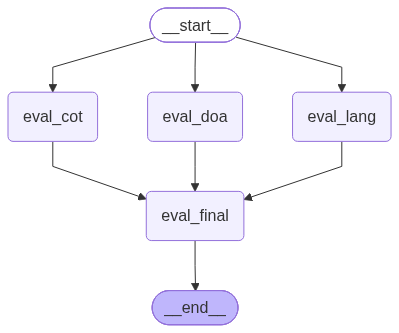

In [153]:
graph.add_node('eval_cot', evaluate_cot)
graph.add_node('eval_doa', evaluate_doa)
graph.add_node('eval_lang', evaluate_lang)
graph.add_node('eval_final', evaluate_overall)

graph.add_edge(START, 'eval_cot')
graph.add_edge(START, 'eval_doa')
graph.add_edge(START, 'eval_lang')
graph.add_edge("eval_cot", "eval_final")
graph.add_edge('eval_doa', "eval_final")
graph.add_edge('eval_lang', "eval_final")
graph.add_edge('eval_final', END)
graph.add_edge('eval_final', END)
graph.add_edge('eval_final', END)

workflow = graph.compile()
workflow


In [154]:
essay = """
# Increasing Income Inequality in India

India has experienced rapid economic growth over the past few decades, transforming itself into one of the world's largest and fastest-growing economies. Millions of people have moved out of poverty, and access to education, technology, infrastructure, and basic services has improved. However, the benefits of economic growth have not been distributed equally. A major challenge facing India today is the growing gap between the rich and the poor. While economic growth has created enormous wealth, a significant share of that wealth and income is concentrated among a relatively small section of society.

Recent estimates highlight the scale of this disparity. The World Inequality Report 2026 estimates that India's richest 10% receive around 58% of national income, while the bottom 50% receive only about 15%. Wealth is even more concentrated than income. At the same time, the World Bank's data shows that extreme poverty has declined substantially, demonstrating that poverty reduction and rising inequality can occur simultaneously.

One of the main reasons for increasing inequality is the uneven distribution of economic opportunities. India's growth has increasingly been driven by sectors such as information technology, finance, services, and capital-intensive industries. These sectors can generate high incomes for skilled workers and business owners, but they cannot provide equally well-paid employment to India's entire workforce. A large proportion of workers continue to depend on agriculture, informal employment, and low-productivity jobs where wages and job security are limited.

Education and skills also play an important role. People with access to quality schools, higher education, professional training, and digital technology have a much greater chance of obtaining high-paying jobs. In contrast, students from poor families and rural areas often face inadequate educational infrastructure and fewer opportunities. This creates an intergenerational cycle in which children from wealthy families are more likely to acquire the skills and networks needed to remain economically successful.

The rural-urban divide further contributes to inequality. Cities provide greater access to high-paying employment, better educational institutions, healthcare, and infrastructure. Rural communities, particularly those dependent on agriculture, often have fewer opportunities to increase their incomes. Similarly, regional differences are significant, with some states having far higher levels of productivity, industrialisation, and employment opportunities than others.

Another important factor is the unequal ownership of assets. Wealthy households are more likely to own businesses, land, stocks, property, and other appreciating assets. As these assets increase in value, their owners accumulate even more wealth. Poorer households, on the other hand, often depend primarily on wages and have limited savings or productive assets. Consequently, wealth can grow much faster for those who already possess substantial capital.

Income inequality also has serious social and economic consequences. When a large proportion of national income is concentrated among a small group, social mobility can decline. People born into poor households may find it difficult to access quality education, healthcare, and productive employment. Excessive inequality can also create social tensions and weaken people's confidence that economic growth is benefiting everyone. Furthermore, when large sections of the population have limited purchasing power, domestic demand and inclusive economic growth can be affected.

However, India's inequality story needs to be understood carefully. Inequality and poverty are not the same thing. India has made considerable progress in reducing extreme poverty. The World Bank estimates that extreme poverty, measured using its revised methodology, fell from 16.2% in 2011–12 to 2.3% in 2022–23. This is an important achievement. The challenge is now to ensure that economic progress also produces broad-based improvements in incomes, employment, and living standards.

Reducing inequality requires long-term structural reforms. India needs to improve the quality of public education and healthcare, expand access to skill development, create more productive employment, and encourage labour-intensive manufacturing. Small businesses and entrepreneurs should receive better access to credit and markets. Social protection programmes should continue to protect vulnerable households, while tax policies can help finance public services without discouraging productive investment. Greater participation of women in the workforce can also significantly expand household incomes and India's productive capacity.

In conclusion, India's economic growth is an achievement, but growth alone is not sufficient. The real measure of development is whether people across different social and economic groups can participate in and benefit from that growth. India has succeeded in reducing extreme poverty, but significant disparities in income, wealth, education, employment, and opportunity remain. The country's future challenge is therefore not simply to grow faster, but to make that growth more inclusive. A more equal India would not only be fairer but would also create a stronger, more productive, and more socially stable economy.

"""

initial_state: EssayState = {
    'essay': essay
}
workflow.invoke(initial_state)

Evaluate the following essay on basis of clarity of thought: 
 
# Increasing Income Inequality in India

India has experienced rapid economic growth over the past few decades, transforming itself into one of the world's largest and fastest-growing economies. Millions of people have moved out of poverty, and access to education, technology, infrastructure, and basic services has improved. However, the benefits of economic growth have not been distributed equally. A major challenge facing India today is the growing gap between the rich and the poor. While economic growth has created enormous wealth, a significant share of that wealth and income is concentrated among a relatively small section of society.

Recent estimates highlight the scale of this disparity. The World Inequality Report 2026 estimates that India's richest 10% receive around 58% of national income, while the bottom 50% receive only about 15%. Wealth is even more concentrated than income. At the same time, the World Bank'

{'essay': "\n# Increasing Income Inequality in India\n\nIndia has experienced rapid economic growth over the past few decades, transforming itself into one of the world's largest and fastest-growing economies. Millions of people have moved out of poverty, and access to education, technology, infrastructure, and basic services has improved. However, the benefits of economic growth have not been distributed equally. A major challenge facing India today is the growing gap between the rich and the poor. While economic growth has created enormous wealth, a significant share of that wealth and income is concentrated among a relatively small section of society.\n\nRecent estimates highlight the scale of this disparity. The World Inequality Report 2026 estimates that India's richest 10% receive around 58% of national income, while the bottom 50% receive only about 15%. Wealth is even more concentrated than income. At the same time, the World Bank's data shows that extreme poverty has declined 